In [1]:
import pandas as pd
import numpy as np

import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("amazonreviews.tsv", sep='\t')
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [3]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("\nAfter Cleaning:")
print(df.isnull().sum())

label     0
review    0
dtype: int64

After Cleaning:
label     0
review    0
dtype: int64


## Data Cleaning

- Checked for missing values and duplicates.
- Removed duplicate records to improve data quality.
- Removed missing values to ensure clean text processing.

This step improves model reliability and prevents noisy data from affecting predictions.

In [4]:
df.shape
# df['label'].value_counts()

(10000, 2)

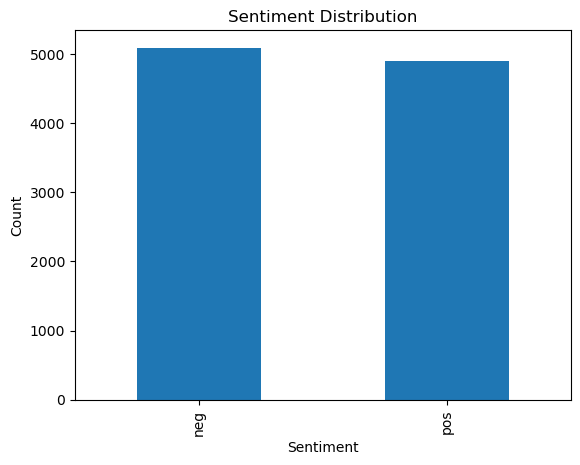

In [5]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

## Sentiment Distribution

- The dataset contains both positive and negative reviews.
- The classes are relatively balanced, reducing the risk of model bias.

In [6]:
import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [7]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rajur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
stop_words = set(stopwords.words('english'))

In [9]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return ' '.join(words)

In [10]:
df['clean_review'] = df['review'].apply(clean_text)

df[['review','clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


## Text Preprocessing

- Converted text to lowercase.
- Removed punctuation and special characters.
- Removed stopwords to reduce noise.

This improves text quality for feature extraction and model training.

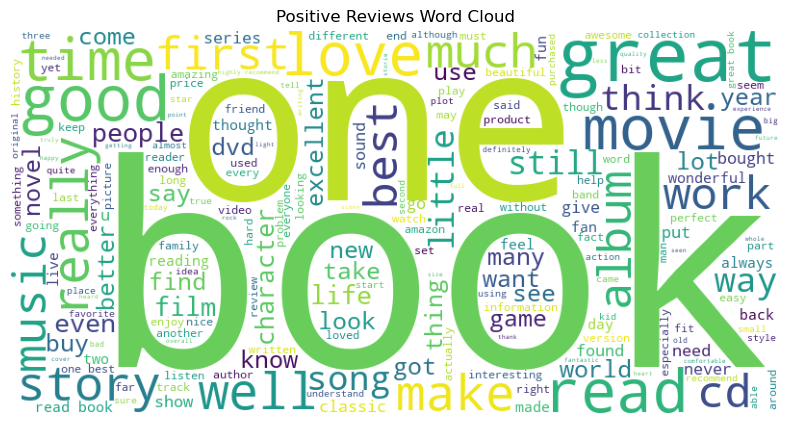

In [11]:
from wordcloud import WordCloud

positive_text = " ".join(df[df['label']=='pos']['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Reviews Word Cloud")

plt.show()

## Word Cloud Analysis

- Frequently occurring words in positive reviews are highlighted.
- This visualization helps understand important terms influencing sentiment.

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])

y = df['label']

In [13]:
print(X.shape)

(10000, 5000)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.851
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1037
         pos       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## Logistic Regression Evaluation

- Logistic Regression achieved good sentiment classification performance.
- Precision, recall, and F1-score are balanced across both classes.

However:
- TF-IDF does not capture word order or semantic meaning.
- Complex sentence structures and sarcasm may still be misclassified.

In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)

print("Average CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.8595 0.83   0.827  0.8455 0.8505]
Average CV Accuracy: 0.8424999999999999


## Cross Validation

- Cross-validation was used to evaluate model stability.
- The model achieved consistent accuracy across multiple folds.

This indicates reasonable generalization performance.

In [19]:
model2 = LinearSVC()

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

In [20]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred2))

print(classification_report(y_test, y_pred2))

SVM Accuracy: 0.8525
              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1037
         pos       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



## Model Comparison

- Logistic Regression and SVM achieved similar performance.
- Both models performed well with TF-IDF features.

However:
- The main limitation is feature representation rather than the model itself.
- Advanced NLP techniques like Word2Vec or BERT could further improve performance.

## Conclusion

- NLP preprocessing and TF-IDF vectorization were successfully implemented.
- Logistic Regression and SVM effectively classified customer reviews.
- Cross-validation confirmed stable model performance.

Overall, the sentiment analysis system effectively predicts review sentiment and demonstrates practical NLP workflow implementation.